# Correlation Between Video Game Critic Review Scores and Global Sales

#### Purpose: A video game publisher would like to better understand if critic review scores are associated with sales. The analysis will examine if higher critic review scores correlate with higher global sales and if the relationship is statistically significant. The results may help the organization evaluate the usefulness of critic reviews as an indicator of market performance. 

H₀: There is no statistically significant correlation between video game critic review scores and global sales.

Hₐ: There is a statistically significant correlation between video game critic review scores and global sales.

#### 1. Data Extraction

In [41]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [23]:
# read in data
df = pd.read_csv('video_games_sales.csv', sep=';')
df.sample(5)

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating,Unnamed: 16,Unnamed: 17
2335,Lego Batman 3: Beyond Gotham,X360,2014,Action,Warner Bros. Interactive Entertainment,"0,48","0,33",0,"0,08","0,89",NaN,NaN,"6,8",14,TT Games,E10+,NaN,NaN
3468,JoJo's Bizarre Adventure: All Star Battle,PS3,2013,Fighting,Namco Bandai Games,"0,05","0,02","0,5","0,01","0,58",71,53,"8,3",55,CyberConnect2,T,NaN,NaN
6740,Major League Baseball 2K7,PS3,2007,Sports,Spike,"0,23",0,0,"0,02","0,25",74,19,"4,7",7,Kush Games,E,NaN,NaN
4707,Ogre Battle 64: Person of Lordly Caliber,N64,1999,Role-Playing,Nintendo,"0,1","0,02","0,25","0,04","0,41",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4340,Pirates of the Caribbean: At World's End,Wii,2007,Action,Disney Interactive Studios,"0,39","0,02","0,01","0,04","0,45",53,17,"7,2",17,Eurocom Entertainment Software,T,NaN,NaN


In [24]:
# take a look at the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Name             16717 non-null  object
 1   Platform         16693 non-null  object
 2   Year_of_Release  16426 non-null  object
 3   Genre            16689 non-null  object
 4   Publisher        16640 non-null  object
 5   NA_Sales         16692 non-null  object
 6   EU_Sales         16693 non-null  object
 7   JP_Sales         16693 non-null  object
 8   Other_Sales      16693 non-null  object
 9   Global_Sales     16693 non-null  object
 10  Critic_Score     8215 non-null   object
 11  Critic_Count     8160 non-null   object
 12  User_Score       10011 non-null  object
 13  User_Count       7594 non-null   object
 14  Developer        10084 non-null  object
 15  Rating           9946 non-null   object
 16  Unnamed: 16      33 non-null     object
 17  Unnamed: 17      2 non-null    

In [ ]:
'''
Workflow list:
1. delete Unnamed 16 and 17
2. Global Sales entry formatting
3. Narrow entries to those with critic scores
4. Possibly get rid of the two rows with no game name
5. Change data types to be usable
6. Duplicates
'''

#### 2. Transform

In [25]:
# There are two extra columns that read in that should not be there. Drop columns
df = df.drop(columns=['Unnamed: 16', 'Unnamed: 17'])

In [26]:
# Check
df.head(2)

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006,Sports,Nintendo,"41,36","28,96","3,77","8,45","82,53",76,51,8,322,Nintendo,E
1,Super Mario Bros.,NES,1985,Platform,Nintendo,"29,08","3,58","6,81","0,77","40,24",NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
# Change formatting for Global_Sales data. Sales are in Millions. Ex: 2,6 == 2.6 million
df['Global_Sales'] = df['Global_Sales'].str.replace(',', '.')
df.head(2)

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006,Sports,Nintendo,"41,36","28,96","3,77","8,45",82.53,76,51,8,322,Nintendo,E
1,Super Mario Bros.,NES,1985,Platform,Nintendo,"29,08","3,58","6,81","0,77",40.24,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
# Change Global Sales to float
df['Global_Sales'] = pd.to_numeric(df['Global_Sales'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16693 non-null  object 
 2   Year_of_Release  16426 non-null  object 
 3   Genre            16689 non-null  object 
 4   Publisher        16640 non-null  object 
 5   NA_Sales         16692 non-null  object 
 6   EU_Sales         16693 non-null  object 
 7   JP_Sales         16693 non-null  object 
 8   Other_Sales      16693 non-null  object 
 9   Global_Sales     16693 non-null  float64
 10  Critic_Score     8215 non-null   object 
 11  Critic_Count     8160 non-null   object 
 12  User_Score       10011 non-null  object 
 13  User_Count       7594 non-null   object 
 14  Developer        10084 non-null  object 
 15  Rating           9946 non-null   object 
dtypes: float64(1), object(15)
memory usage: 2.0+ MB


In [29]:
# there are only 8215 rows with critic scores. Critic scores is needed for analysis. Remove rows without a critic score
df = df.dropna(subset=['Critic_Score'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8215 entries, 0 to 16709
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             8215 non-null   object 
 1   Platform         8215 non-null   object 
 2   Year_of_Release  8063 non-null   object 
 3   Genre            8213 non-null   object 
 4   Publisher        8211 non-null   object 
 5   NA_Sales         8214 non-null   object 
 6   EU_Sales         8215 non-null   object 
 7   JP_Sales         8215 non-null   object 
 8   Other_Sales      8215 non-null   object 
 9   Global_Sales     8215 non-null   float64
 10  Critic_Score     8215 non-null   object 
 11  Critic_Count     8160 non-null   object 
 12  User_Score       8101 non-null   object 
 13  User_Count       7022 non-null   object 
 14  Developer        8125 non-null   object 
 15  Rating           8056 non-null   object 
dtypes: float64(1), object(15)
memory usage: 1.1+ MB


In [32]:
# Change Critic Score data type
df['Critic_Score'] = pd.to_numeric(
    df['Critic_Score'].str.replace(',', '.'),
    errors= 'coerce'
)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8215 entries, 0 to 16709
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             8215 non-null   object 
 1   Platform         8215 non-null   object 
 2   Year_of_Release  8063 non-null   object 
 3   Genre            8213 non-null   object 
 4   Publisher        8211 non-null   object 
 5   NA_Sales         8214 non-null   object 
 6   EU_Sales         8215 non-null   object 
 7   JP_Sales         8215 non-null   object 
 8   Other_Sales      8215 non-null   object 
 9   Global_Sales     8215 non-null   float64
 10  Critic_Score     8215 non-null   float64
 11  Critic_Count     8160 non-null   object 
 12  User_Score       8101 non-null   object 
 13  User_Count       7022 non-null   object 
 14  Developer        8125 non-null   object 
 15  Rating           8056 non-null   object 
dtypes: float64(2), object(14)
memory usage: 1.1+ MB


In [34]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

In [33]:
# Check data set for anything else that needs changing
df[['Critic_Score', 'Global_Sales']].describe()

,Critic_Score,Global_Sales
count,8215.000000,8215.000000
mean,68.059565,0.681848
std,15.931315,1.809456
min,0.000000,0.000000
25%,60.000000,0.090000
50%,70.000000,0.240000
75%,79.000000,0.640000
max,98.000000,82.530000


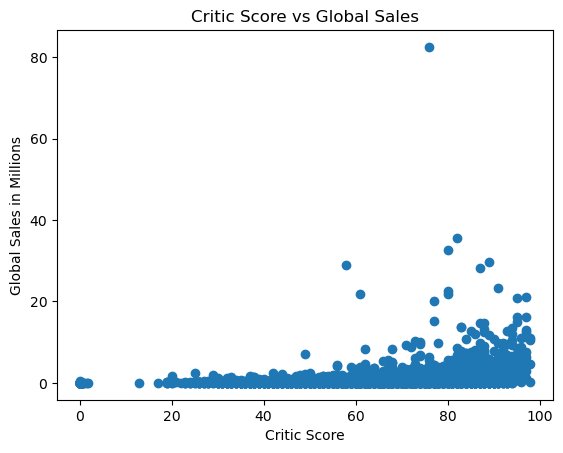

In [36]:
# scatter plot to visualize data
# create scatter plot function
def create_scatter_plot(title, xlabel, ylabel, col1, col2, data):
    plt.scatter(data[col1], data[col2])
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

# call function
create_scatter_plot(
    "Critic Score vs Global Sales",
    "Critic Score",
    "Global Sales in Millions",
    "Critic_Score",
    "Global_Sales",
    df
)

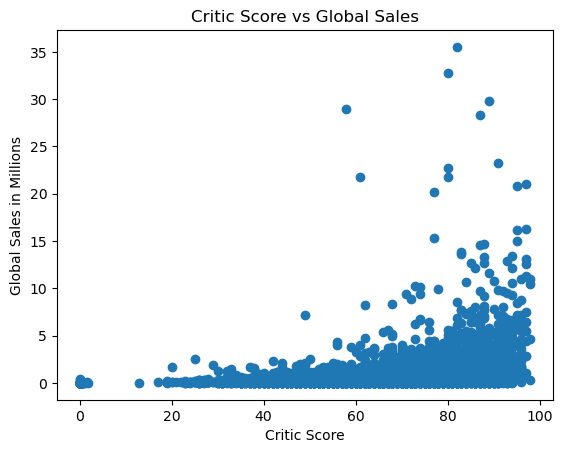

In [37]:
# there appears to be one outlier that's over 80 million sales. I'll keep this dataset for credibility.
# create a second dataset with no outliers, sales under 40 million for comparison

df_no_outlier = df[df['Global_Sales'] < 40]
create_scatter_plot(
    "Critic Score vs Global Sales",
    "Critic Score",
    "Global Sales in Millions",
    "Critic_Score",
    "Global_Sales",
    df_no_outlier
)

#### 3. Analysis

A Pearson Correlation Test will be used to measure linear relationship, strength, and direction. Regression will be used for prediction and slope interpretation.

A significance level of 0.05 will be used. α = 0.05

p < 0.05 -> Statistically significant

p >= 0.05  -> Not Statistically significant

In [39]:
# Calculate correlation between critic score and global sales, original data set
df[['Critic_Score', 'Global_Sales']].corr()

,Critic_Score,Global_Sales
Critic_Score,1.000000,0.234609
Global_Sales,0.234609,1.000000


For the main data set with outliers the correlation coefficient is 0.234609. This shows a positive but weak correlation. This association shows that as critic scores increase, global sales increase slightly.

In [40]:
# Calculate correlation between critic score and global sales, no outlier data set
df_no_outlier[['Critic_Score', 'Global_Sales']].corr()

,Critic_Score,Global_Sales
Critic_Score,1.000000,0.267581
Global_Sales,0.267581,1.000000


For the data set without outliers the correlation coefficient is 0.267581. This shows a positive but weak correlation. Removing the outlier has made the correlation slightly stronger but it is still a weak correlation. This association shows that as critic scores increase, global sales increase slightly.

In [43]:
# linear regression for original data set
slope, intercept, r_value, p_value, std_err = linregress(
    df['Critic_Score'],
    df['Global_Sales']
)

print('Slope: ', slope)
print('Intercept: ', intercept),
print('R-squared: ', r_value**2),
print('P-value: ', p_value)

Slope:  0.026646507713725877
Intercept:  -1.131701895880841
R-squared:  0.055041185906998795
P-value:  4.0403768689869913e-103


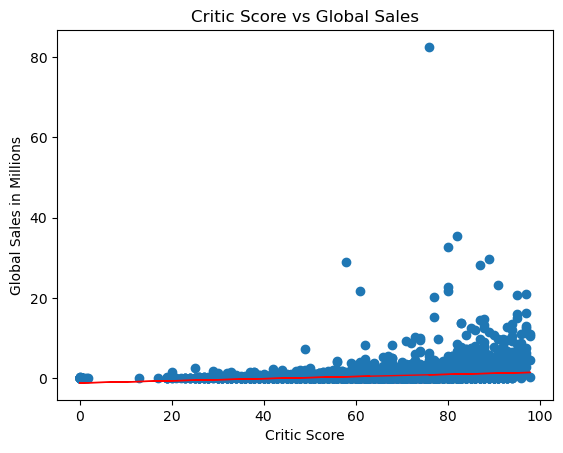

In [47]:
# plot the regression

# create regression visualization function
def create_reg_viz(title, xlabel, ylabel, col1, col2, data):
    plt.scatter(data[col1], data[col2])
    
    x = data[col1]
    y = slope * x + intercept

    plt.plot(x,y, color= 'red', linewidth=1)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

# call function
create_reg_viz(
    "Critic Score vs Global Sales",
    "Critic Score",
    "Global Sales in Millions",
    "Critic_Score",
    "Global_Sales",
    df
)

Results:
* Correlation ~0.23
* Slope ~0.0266
* R^2 ~0.055
* P-value 4.04e-103
* α = 0.05

The analysis shows a weak positive correlation between critic scores and global sales. Although the strength of the relationship is statistically significant (p-value < α), the strength of the association is very low R^2 ≈ 0.055, indicating the critic scores explain only 5.5% of the variation in global sales. The regression line confirms a slight positive correlation.

In [49]:
# linear regression for data set without outliers
slope, intercept, r_value, p_value, std_err = linregress(
    df_no_outlier['Critic_Score'],
    df_no_outlier['Global_Sales']
)

print('Slope: ', slope)
print('Intercept: ', intercept),
print('R-squared: ', r_value**2),
print('P-value: ', p_value)

Slope:  0.0263355244135605
Intercept:  -1.1204755186521824
R-squared:  0.07159969859546315
P-value:  1.0904202482513095e-134


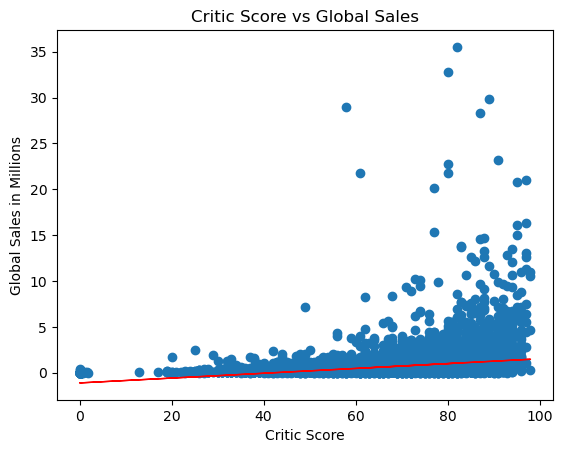

In [50]:
# plot the regression
# call function
create_reg_viz(
    "Critic Score vs Global Sales",
    "Critic Score",
    "Global Sales in Millions",
    "Critic_Score",
    "Global_Sales",
    df_no_outlier
)

Results:
* Correlation ~0.268
* Slope ~0.026
* R^2 ~0.072
* P-value 1.09e-134
* α = 0.05

The analysis of the data without outliers shows a weak positive correlation between critic scores and global sales. The strength of the relationship is statistically significant (p-value < α). The strength of the association is very low R^2 ≈ 0.072 but higher than the analysis with outliers, indicating the critic scores explain only 7.2% of the variation in global sales. The regression line confirms a slight positive correlation.